In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from math import comb
try:
    from helper_functions import PROCESSED_DIR
except ImportError:
    PROJECT_ROOT = Path.cwd()

    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

    PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

PLOTS_DIR = PROCESSED_DIR / "plots" / "genre_assignment_approach_comparison"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

In [14]:
selected_modality = "vgg19"
total_genres = 50
min_tracks = 20

approaches = {
    "Approach 1: Metadata": {
        "dir": PROCESSED_DIR / "09_selected_genres_metadata",
        "prefix": "metadata_top50_mintracks20_genrepositionfirst",
    },
    "Approach 2: Local optimization": {
        "dir": PROCESSED_DIR / "09_selected_genres_local_optimization",
        "prefix": "localopt_top50_mintracks20_topcandidates5_genrepool180",
    },
    "Approach 3: OR-Tools": {
        "dir": PROCESSED_DIR / "09_selected_genres_ortools",
        "prefix": "ortools_top50_mintracks20_topcandidates5_genrepool180",
    },
}

In [15]:
def load_approach_outputs(approach_config):
    base_dir = approach_config["dir"]
    prefix = approach_config["prefix"]

    coverage = pd.read_parquet(
        base_dir / f"{prefix}_genre_window_coverage.parquet"
    )

    selected = pd.read_csv(
        base_dir / f"{prefix}_selected_genres.csv"
    )

    summary_path = base_dir / f"{prefix}_coverage_summary.csv"

    if summary_path.exists():
        summary = pd.read_csv(summary_path)
    else:
        summary = None

    if "selection_rank" in selected.columns:
        selected_genres = (
            selected
            .sort_values("selection_rank")["genre"]
            .tolist()
        )
    else:
        selected_genres = selected["genre"].tolist()

    return coverage, selected, selected_genres, summary

In [16]:
loaded = {}

for approach_name, config in approaches.items():
    coverage, selected, selected_genres, summary = load_approach_outputs(config)

    loaded[approach_name] = {
        "coverage": coverage,
        "selected": selected,
        "selected_genres": selected_genres,
        "summary": summary,
    }

    print(approach_name)
    print("Selected genres:", len(set(selected_genres)))
    print("Coverage genres:", coverage["genre"].nunique())
    print("Modalities:", sorted(coverage["modality"].unique()))
    print()

Approach 1: Metadata
Selected genres: 50
Coverage genres: 50
Modalities: ['essentia', 'lyrics_tf_idf', 'mfcc', 'musicnn', 'vgg19', 'word2vec']

Approach 2: Local optimization
Selected genres: 50
Coverage genres: 50
Modalities: ['essentia', 'lyrics_tf_idf', 'mfcc', 'musicnn', 'vgg19', 'word2vec']

Approach 3: OR-Tools
Selected genres: 50
Coverage genres: 50
Modalities: ['essentia', 'lyrics_tf_idf', 'mfcc', 'musicnn', 'vgg19', 'word2vec']



In [17]:
def make_eligibility_matrix(coverage, selected_genres, selected_modality):
    modality_coverage = coverage[
        coverage["modality"] == selected_modality
    ].copy()

    matrix_data = modality_coverage[
        modality_coverage["genre"].isin(selected_genres)
    ].pivot_table(
        index="genre",
        columns="window_start",
        values="eligible_window",
        aggfunc="max",
        fill_value=False,
    )

    matrix_data = (
        matrix_data
        .reindex(selected_genres)
        .fillna(False)
        .astype(bool)
        .astype(int)
    )

    return matrix_data

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/data/processed/plots/genre_assignment_approach_comparison/assignment_approach_comparison_top50_vgg19_sorted.png


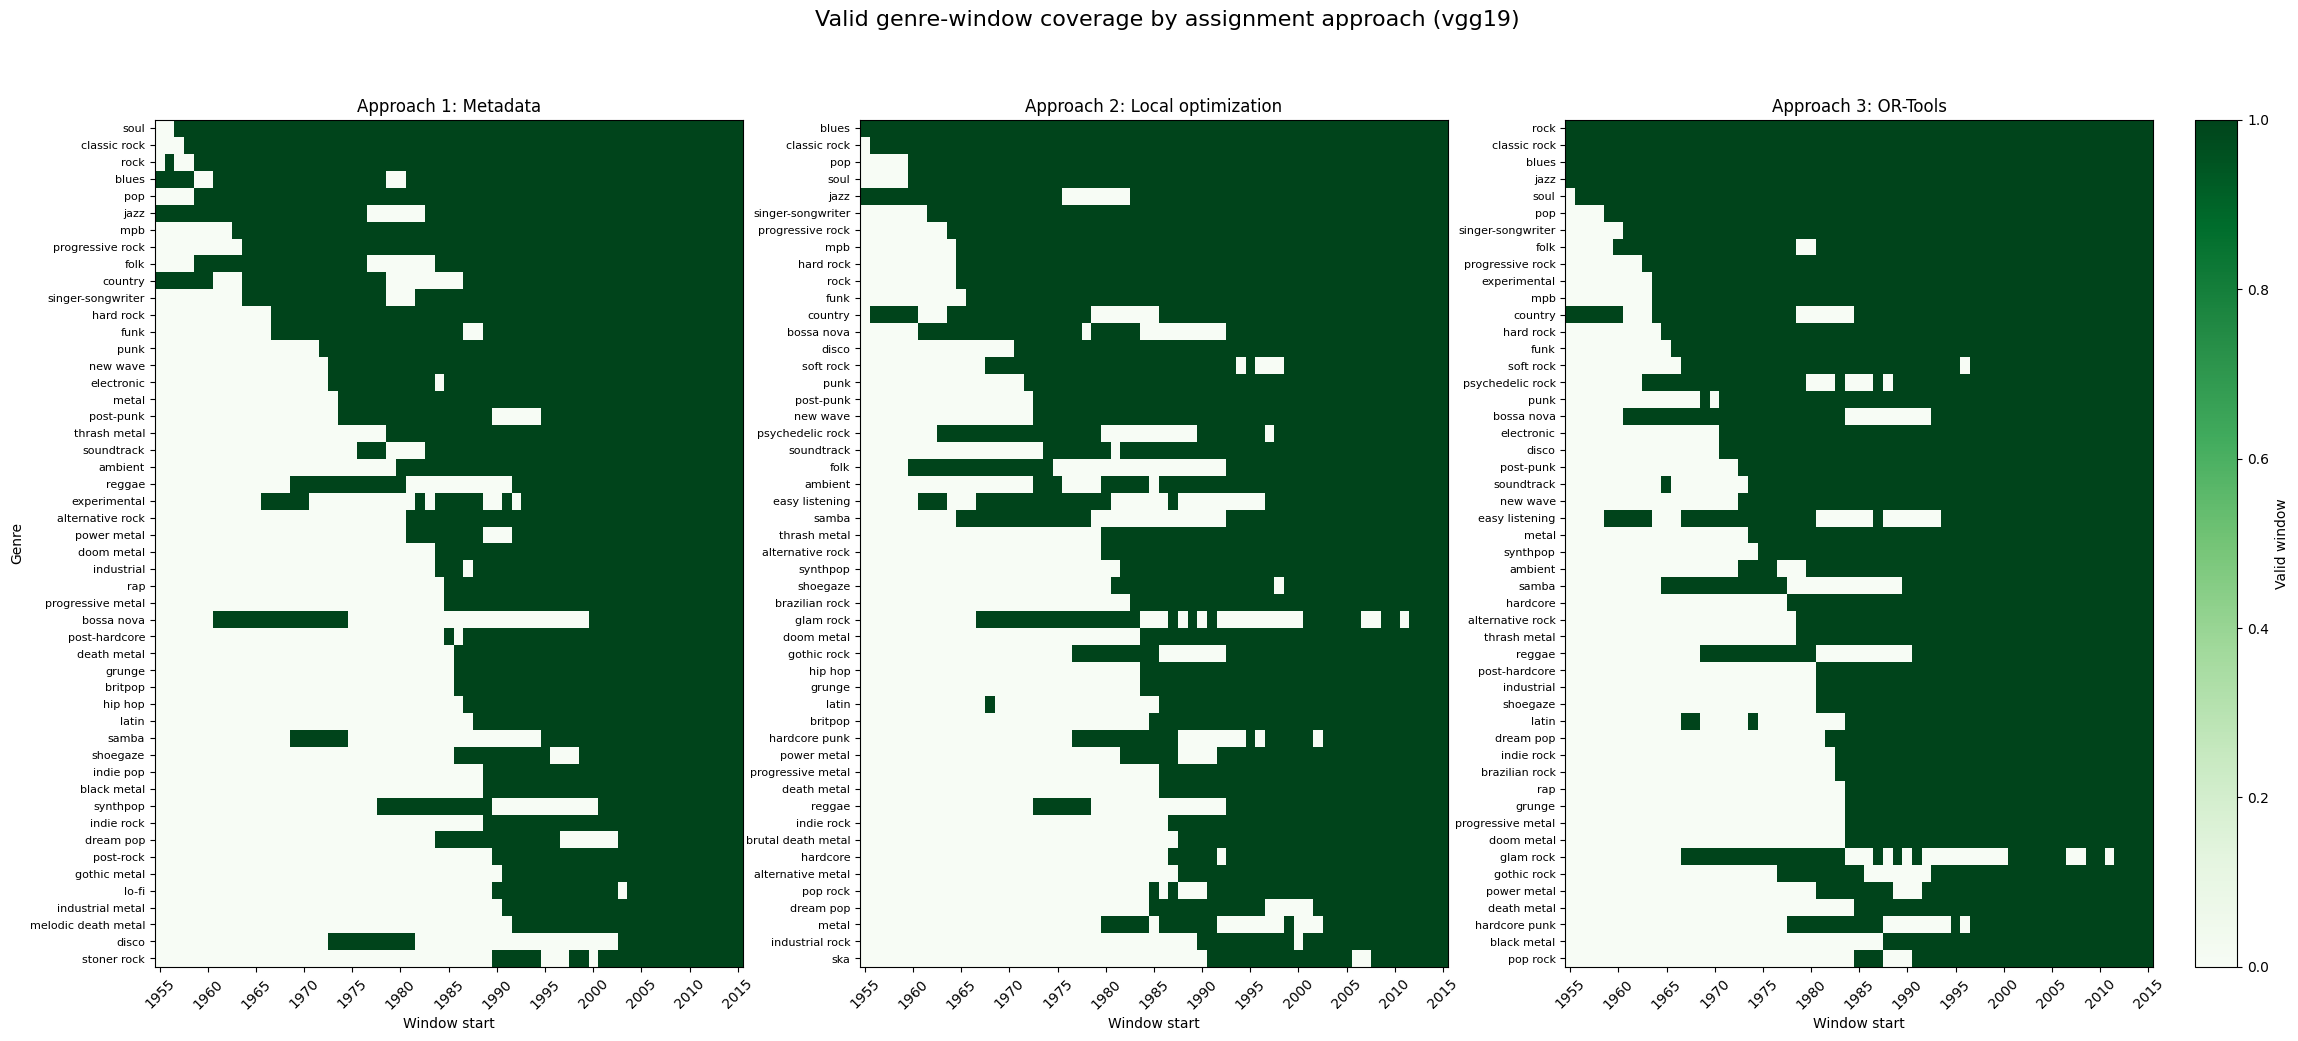

In [18]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(27, 11),
    sharex=True,
)

last_image = None

for ax, (approach_name, data) in zip(axes, loaded.items()):
    matrix_data = make_eligibility_matrix(
        coverage=data["coverage"],
        selected_genres=data["selected_genres"],
        selected_modality=selected_modality,
    )

    genre_coverage = matrix_data.sum(axis=1)

    matrix_data = matrix_data.loc[
        genre_coverage.sort_values(ascending=False).index
    ]

    last_image = ax.imshow(
        matrix_data.to_numpy(),
        aspect="auto",
        cmap="Greens",
        vmin=0,
        vmax=1,
    )

    ax.set_title(approach_name)
    ax.set_xlabel("Window start")

    ax.set_yticks(range(len(matrix_data.index)))
    ax.set_yticklabels(matrix_data.index, fontsize=8)

    ax.set_xticks(range(0, len(matrix_data.columns), 5))
    ax.set_xticklabels(matrix_data.columns[::5], rotation=45)

axes[0].set_ylabel("Genre")

fig.suptitle(
    f"Valid genre-window coverage by assignment approach ({selected_modality})",
    fontsize=16,
)

fig.colorbar(
    last_image,
    ax=axes,
    label="Valid window",
    fraction=0.025,
    pad=0.02,
)

output_path = (
    PLOTS_DIR
    / f"assignment_approach_comparison_top{total_genres}_{selected_modality}_sorted.png"
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

In [19]:
comparison_rows = []

for approach_name, data in loaded.items():
    coverage = data["coverage"]
    selected_genres = set(data["selected_genres"])

    selected_coverage = coverage[
        (coverage["modality"] == selected_modality)
        & (coverage["genre"].isin(selected_genres))
    ].copy()

    n_valid_cells = int(selected_coverage["eligible_window"].sum())
    n_possible_cells = (
        selected_coverage["genre"].nunique()
        * selected_coverage["window_start"].nunique()
    )

    comparison_rows.append({
        "approach": approach_name,
        "modality": selected_modality,
        "n_selected_genres": len(selected_genres),
        "n_windows": selected_coverage["window_start"].nunique(),
        "valid_genre_windows": n_valid_cells,
        "possible_genre_windows": n_possible_cells,
        "valid_share": n_valid_cells / n_possible_cells,
    })

comparison = pd.DataFrame(comparison_rows)
comparison

,approach,modality,n_selected_genres,n_windows,valid_genre_windows,possible_genre_windows,valid_share
0,Approach 1: Metadata,vgg19,50,61,1838,3050,0.602623
1,Approach 2: Local optimization,vgg19,50,61,1926,3050,0.631475
2,Approach 3: OR-Tools,vgg19,50,61,2119,3050,0.694754


/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/data/processed/plots/genre_assignment_approach_comparison/assignment_approach_valid_share_top50_vgg19.png


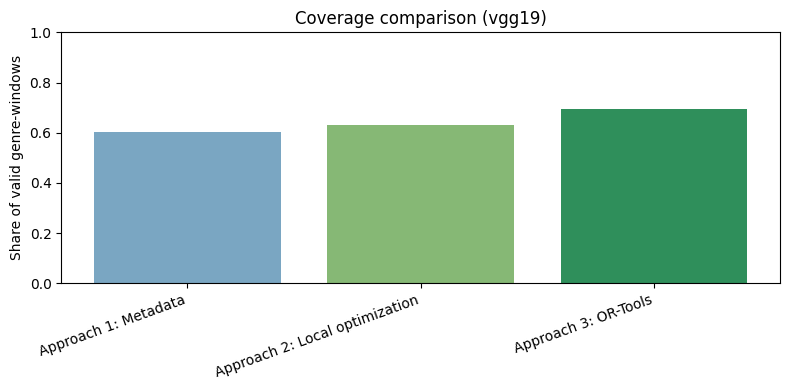

In [20]:
plt.figure(figsize=(8, 4))

plt.bar(
    comparison["approach"],
    comparison["valid_share"],
    color=["#7aa6c2", "#86b875", "#2f8f5b"],
)

plt.ylabel("Share of valid genre-windows")
plt.ylim(0, 1)
plt.title(f"Coverage comparison ({selected_modality})")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

output_path = (
    PLOTS_DIR
    / f"assignment_approach_valid_share_top{total_genres}_{selected_modality}.png"
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()